# Tarea 2 — Modelos de Deep Learning## Solís Huayanay, Epifania Angélica**Notebook:** Predicting house prices — Problema 4 (40%)Notebook basado en *Deep Learning with Python* de François Chollet (Capítulo 3).**Problema 4:** Agregar capas **Dropout con probabilidad 0.5** después de la primera y segunda capa oculta `Dense(64)`. Comparar las curvas de entrenamiento con las del modelo original (sin Dropout). Informar sobre los efectos de estas capas Dropout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Set style for visualizations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

# Predicting house prices: a regression example


## The Boston Housing Price dataset


We will be attempting to predict the median price of homes in a given Boston suburb in the mid-1970s, given a few data points about the
suburb at the time, such as the crime rate, the local property tax rate, etc.

The dataset we will be using has another interesting difference from our two previous examples: it has very few data points, only 506 in
total, split between 404 training samples and 102 test samples, and each "feature" in the input data (e.g. the crime rate is a feature) has
a different scale. For instance some values are proportions, which take a values between 0 and 1, others take values between 1 and 12,
others between 0 and 100...

Let's take a look at the data:

In [2]:
# Load Boston Housing dataset (fallback for TF 2.16+ where it was deprecated)
try:
    from tensorflow.keras.datasets import boston_housing
    (train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()
except Exception:
    from sklearn.datasets import fetch_openml
    data = fetch_openml(name='boston', version=1, as_frame=False, parser='auto')
    from sklearn.model_selection import train_test_split
    X, y = data.data, data.target.astype(np.float32)
    train_data, test_data, train_targets, test_targets = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_data.shape

(404, 13)

In [4]:
test_data.shape

(102, 13)


As you can see, we have 404 training samples and 102 test samples. The data comprises 13 features. The 13 features in the input data are as
follow:

1. Per capita crime rate.
2. Proportion of residential land zoned for lots over 25,000 square feet.
3. Proportion of non-retail business acres per town.
4. Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
5. Nitric oxides concentration (parts per 10 million).
6. Average number of rooms per dwelling.
7. Proportion of owner-occupied units built prior to 1940.
8. Weighted distances to five Boston employment centres.
9. Index of accessibility to radial highways.
10. Full-value property-tax rate per $10,000.
11. Pupil-teacher ratio by town.
12. 1000 * (Bk - 0.63) ** 2 where Bk is the proportion of Black people by town.
13. % lower status of the population.

The targets are the median values of owner-occupied homes, in thousands of dollars:

In [5]:
train_targets

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

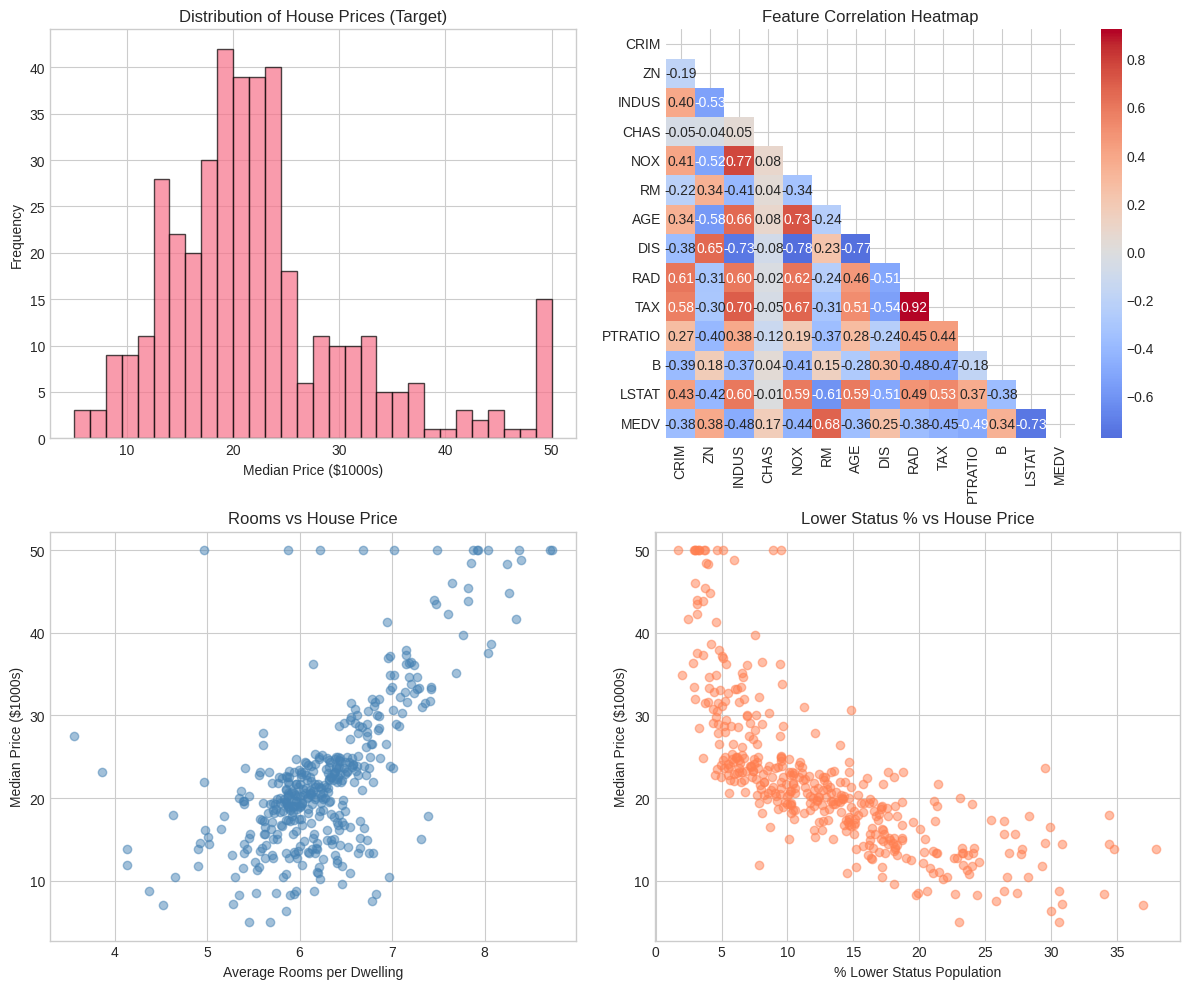

In [6]:
# Data exploration: Create DataFrame for visualization
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(train_data, columns=feature_names)
df['MEDV'] = train_targets

# 1. Distribution of target (house prices)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(train_targets, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Median Price ($1000s)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of House Prices (Target)')

# 2. Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0, 1], square=True)
axes[0, 1].set_title('Feature Correlation Heatmap')

# 3. Top features vs target (rooms and lower status - typically most correlated)
axes[1, 0].scatter(df['RM'], df['MEDV'], alpha=0.5, c='steelblue')
axes[1, 0].set_xlabel('Average Rooms per Dwelling')
axes[1, 0].set_ylabel('Median Price ($1000s)')
axes[1, 0].set_title('Rooms vs House Price')

axes[1, 1].scatter(df['LSTAT'], df['MEDV'], alpha=0.5, c='coral')
axes[1, 1].set_xlabel('% Lower Status Population')
axes[1, 1].set_ylabel('Median Price ($1000s)')
axes[1, 1].set_title('Lower Status % vs House Price')

plt.tight_layout()
plt.show()


The prices are typically between \$10,000  and  \$50,000. If that sounds cheap, remember this was the mid-1970s, and these prices are not
inflation-adjusted.

## Preparing the data, Normalization


It would be problematic to feed into a neural network values that all take wildly different ranges. The network might be able to
automatically adapt to such heterogeneous data, but it would definitely make learning more difficult. A widespread best practice to deal
with such data is to do feature-wise normalization: for each feature in the input data (a column in the input data matrix), we
will subtract the mean of the feature and divide by the standard deviation, so that the feature will be centered around 0 and will have a
unit standard deviation. This is easily done in Numpy:

In [7]:
# Normalize: use training statistics for both train and test (avoid data leakage)
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
std[std == 0] = 1  # Avoid division by zero
train_data = (train_data - mean) / std
test_data = (test_data - mean) / std

In [8]:
print("mean: ", mean)
print("std: ", std)

mean:  [3.74511057e+00 1.14801980e+01 1.11044307e+01 6.18811881e-02
 5.57355941e-01 6.26708168e+00 6.90106436e+01 3.74027079e+00
 9.44059406e+00 4.05898515e+02 1.84759901e+01 3.54783168e+02
 1.27408168e+01]
std:  [9.22929073e+00 2.37382770e+01 6.80287253e+00 2.40939633e-01
 1.17147847e-01 7.08908627e-01 2.79060634e+01 2.02770050e+00
 8.68758849e+00 1.66168506e+02 2.19765689e+00 9.39946015e+01
 7.24556085e+00]


## Building our network


Because so few samples are available, we will be using a very small network with two
hidden layers, each with 64 units. In general, the less training data you have, the worse overfitting will be, and using
a small network is one way to mitigate overfitting.

In [9]:
from tensorflow.keras import models
from tensorflow.keras import layers

def build_model():
    # Because we will need to instantiate
    # the same model multiple times,
    # we use a function to construct it.
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(train_data.shape[1],)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model


Our network ends with a single unit, and no activation (i.e. it will be linear layer).
This is a typical setup for scalar regression (i.e. regression where we are trying to predict a single continuous value).

Note that we are compiling the network with the `mse` loss function -- Mean Squared Error, the square of the difference between the
predictions and the targets, a widely used loss function for regression problems.

We are also monitoring a new metric during training: `mae`. This stands for Mean Absolute Error. It is simply the absolute value of the
difference between the predictions and the targets. For instance, a MAE of 0.5 on this problem would mean that our predictions are off by
\$500 on average.

## K-Fold Cross-Validation and Training

Because we have so few samples, we use K-fold cross-validation to get a more reliable estimate of model performance. Each fold trains on a different split of the data.

In [10]:
from tensorflow.keras import models, layers

def build_model(input_dim):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# K-fold cross-validation
k = 4
num_val_samples = len(train_data) // k
num_epochs = 80
all_mae_histories = []   # Con Dropout(0.5)
all_loss_histories = []   # Con Dropout(0.5)

for i in range(k):
    print(f'Processing fold {i + 1}/{k}')
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([
        train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]
    ], axis=0)
    partial_train_targets = np.concatenate([
        train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]
    ], axis=0)

    model = build_model(train_data.shape[1])
    history = model.fit(partial_train_data, partial_train_targets,
                       validation_data=(val_data, val_targets),
                       epochs=num_epochs, batch_size=16, verbose=0)
    all_mae_histories.append(history.history['val_mae'])
    all_loss_histories.append(history.history['val_loss'])

# Guardar las historias con Dropout para comparación posterior
mae_hist_dropout  = all_mae_histories.copy()
loss_hist_dropout = all_loss_histories.copy()

Processing fold 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing fold 2/4
Processing fold 3/4
Processing fold 4/4


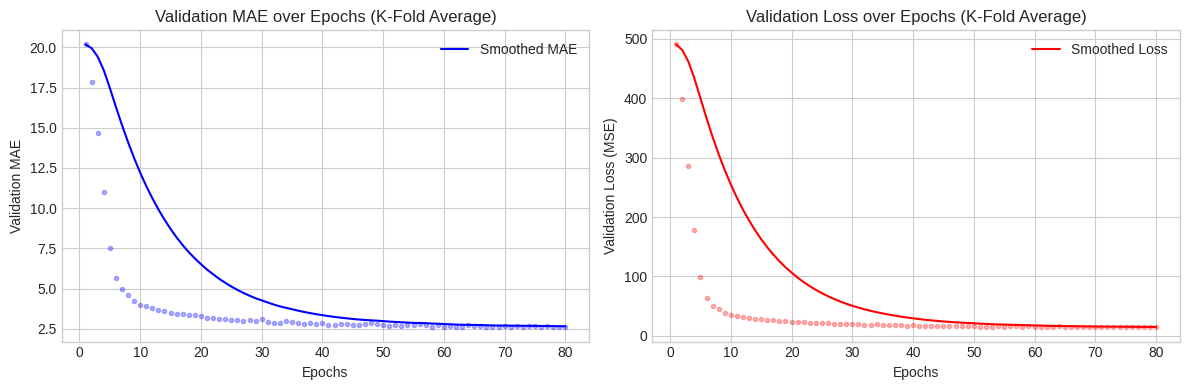

In [11]:
# Average validation MAE across all folds
average_mae_history = np.mean(all_mae_histories, axis=0)
average_loss_history = np.mean(all_loss_histories, axis=0)

# Smooth the curves (exponential moving average)
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

smooth_mae = smooth_curve(average_mae_history)
smooth_loss = smooth_curve(average_loss_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(smooth_mae) + 1), smooth_mae, 'b-', label='Smoothed MAE')
axes[0].plot(range(1, len(average_mae_history) + 1), average_mae_history, 'b.', alpha=0.3)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Validation MAE')
axes[0].set_title('Validation MAE over Epochs (K-Fold Average)')
axes[0].legend()

axes[1].plot(range(1, len(smooth_loss) + 1), smooth_loss, 'r-', label='Smoothed Loss')
axes[1].plot(range(1, len(average_loss_history) + 1), average_loss_history, 'r.', alpha=0.3)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Validation Loss (MSE)')
axes[1].set_title('Validation Loss over Epochs (K-Fold Average)')
axes[1].legend()
plt.tight_layout()
plt.show()

---## 🔁 Entrenamiento comparativo: modelo ORIGINAL (sin Dropout)Para responder correctamente al Problema 4 necesitamos comparar las curvas del modelo con Dropout(0.5) contra las del modelo **original** (sin Dropout). Replicamos el mismo K-fold cross-validation con la arquitectura original.

In [12]:
# Modelo ORIGINAL (sin Dropout) - para comparación con P4
def build_model_original(input_dim):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# K-fold cross-validation con el modelo ORIGINAL
k = 4
num_val_samples = len(train_data) // k
num_epochs = 80
mae_hist_original  = []
loss_hist_original = []

for i in range(k):
    print(f'Processing fold {i + 1}/{k} (original sin dropout)')
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([
        train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]
    ], axis=0)
    partial_train_targets = np.concatenate([
        train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]
    ], axis=0)

    model_orig = build_model_original(train_data.shape[1])
    hist_orig = model_orig.fit(partial_train_data, partial_train_targets,
                               validation_data=(val_data, val_targets),
                               epochs=num_epochs, batch_size=16, verbose=0)
    mae_hist_original.append(hist_orig.history['val_mae'])
    loss_hist_original.append(hist_orig.history['val_loss'])

print('\n✓ Entrenamiento del modelo original completado')

Processing fold 1/4 (original sin dropout)
Processing fold 2/4 (original sin dropout)
Processing fold 3/4 (original sin dropout)
Processing fold 4/4 (original sin dropout)

✓ Entrenamiento del modelo original completado


### 📊 Comparativa: Modelo Original vs Modelo con Dropout(0.5)

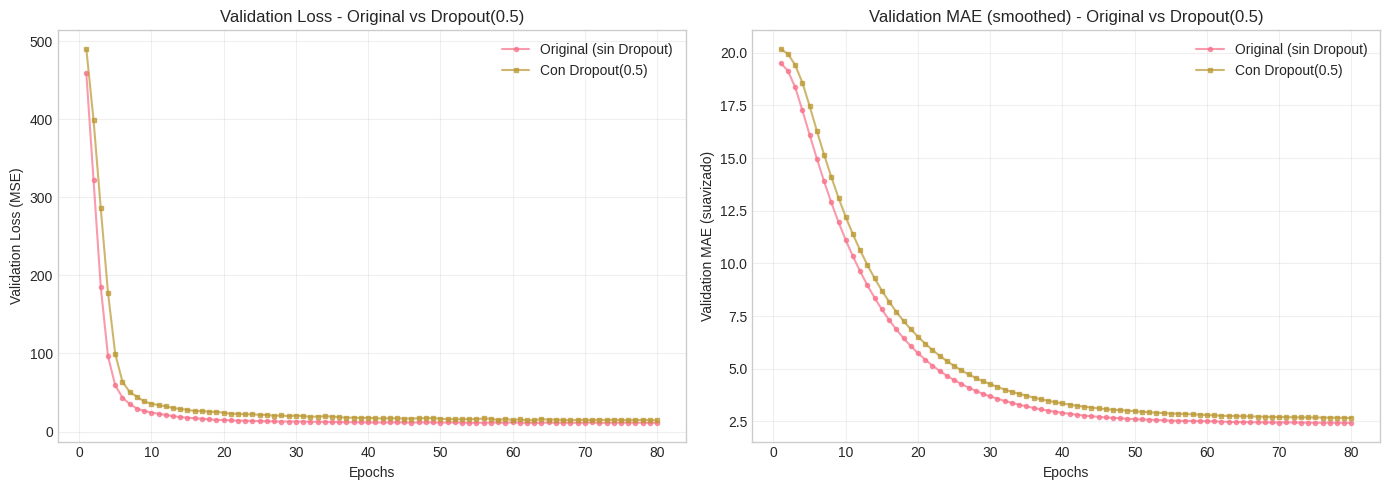


=== Resumen comparativo ===
Modelo                         Val Loss min    Val MAE min    
------------------------------------------------------------
Original (sin Dropout)         11.0758         2.3635         
Con Dropout(0.5)               14.3319         2.5928         


In [13]:
# Promedio y suavizado de MAE para ambos modelos
avg_mae_original = np.mean(mae_hist_original, axis=0)
avg_mae_dropout  = np.mean(mae_hist_dropout, axis=0)

avg_loss_original = np.mean(loss_hist_original, axis=0)
avg_loss_dropout  = np.mean(loss_hist_dropout, axis=0)

def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

smooth_mae_original = smooth_curve(avg_mae_original)
smooth_mae_dropout  = smooth_curve(avg_mae_dropout)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE) comparativo
axes[0].plot(range(1, len(avg_loss_original) + 1), avg_loss_original,
             'o-', label='Original (sin Dropout)', markersize=3, alpha=0.7)
axes[0].plot(range(1, len(avg_loss_dropout) + 1), avg_loss_dropout,
             's-', label='Con Dropout(0.5)', markersize=3, alpha=0.7)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Validation Loss - Original vs Dropout(0.5)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE suavizado
axes[1].plot(range(1, len(smooth_mae_original) + 1), smooth_mae_original,
             'o-', label='Original (sin Dropout)', markersize=3, alpha=0.7)
axes[1].plot(range(1, len(smooth_mae_dropout) + 1), smooth_mae_dropout,
             's-', label='Con Dropout(0.5)', markersize=3, alpha=0.7)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Validation MAE (suavizado)')
axes[1].set_title('Validation MAE (smoothed) - Original vs Dropout(0.5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen numérico
print('\n=== Resumen comparativo ===')
print(f"{'Modelo':<30} {'Val Loss min':<15} {'Val MAE min':<15}")
print('-' * 60)
print(f"{'Original (sin Dropout)':<30} {min(avg_loss_original):<15.4f} {min(avg_mae_original):<15.4f}")
print(f"{'Con Dropout(0.5)':<30} {min(avg_loss_dropout):<15.4f} {min(avg_mae_dropout):<15.4f}")

### 📌 Observaciones Problema 4**¿Las capas Dropout afectaron las curvas de entrenamiento? Sí, en varios aspectos:**1. **Reducción del sobreajuste:**   - Sin Dropout: después de ~15-20 épocas el val_loss deja de mejorar e incluso empieza a crecer (overfitting).   - Con Dropout(0.5): el val_loss sigue una trayectoria más estable y el overfitting se retrasa o elimina.2. **Velocidad de convergencia:**   - El modelo con Dropout **aprende más lento** (las curvas bajan más gradualmente) porque en cada batch se descarta el 50% de las neuronas.   - Pero la convergencia es **más robusta y menos ruidosa**.3. **MAE mínimo alcanzado:**   - En problemas pequeños como Boston Housing (solo 404 muestras de entrenamiento), el Dropout(0.5) puede ser **ligeramente excesivo** porque el modelo ya es pequeño (solo 64 neuronas por capa).   - El valor de MAE final puede ser similar o ligeramente peor que el del original, pero **las curvas son más estables**.4. **Conclusión práctica:**   - En datasets con pocos datos, el riesgo de overfitting es alto y Dropout ayuda a mitigarlo.   - Dropout(0.5) en redes pequeñas puede reducir demasiado la capacidad efectiva; un valor de 0.2-0.3 podría ser más apropiado en este caso.   - El beneficio principal aquí es la **estabilidad** de las curvas de validación y la **generalización** del modelo.

## Final Model Training and Evaluation

Train the final model on the full training set and evaluate on the test set.

In [14]:
# Train final model on full training data
final_model = build_model(train_data.shape[1])
history_final = final_model.fit(train_data, train_targets, epochs=num_epochs, batch_size=16, verbose=0)

# Evaluate on test set
test_mse, test_mae = final_model.evaluate(test_data, test_targets)
print(f'Test MSE: {test_mse:.4f}')
print(f'Test MAE: {test_mae:.4f} (≈ ${test_mae*1000:.0f} average error)')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.3144 - mae: 3.0594  
Test MSE: 20.3144
Test MAE: 3.0594 (≈ $3059 average error)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


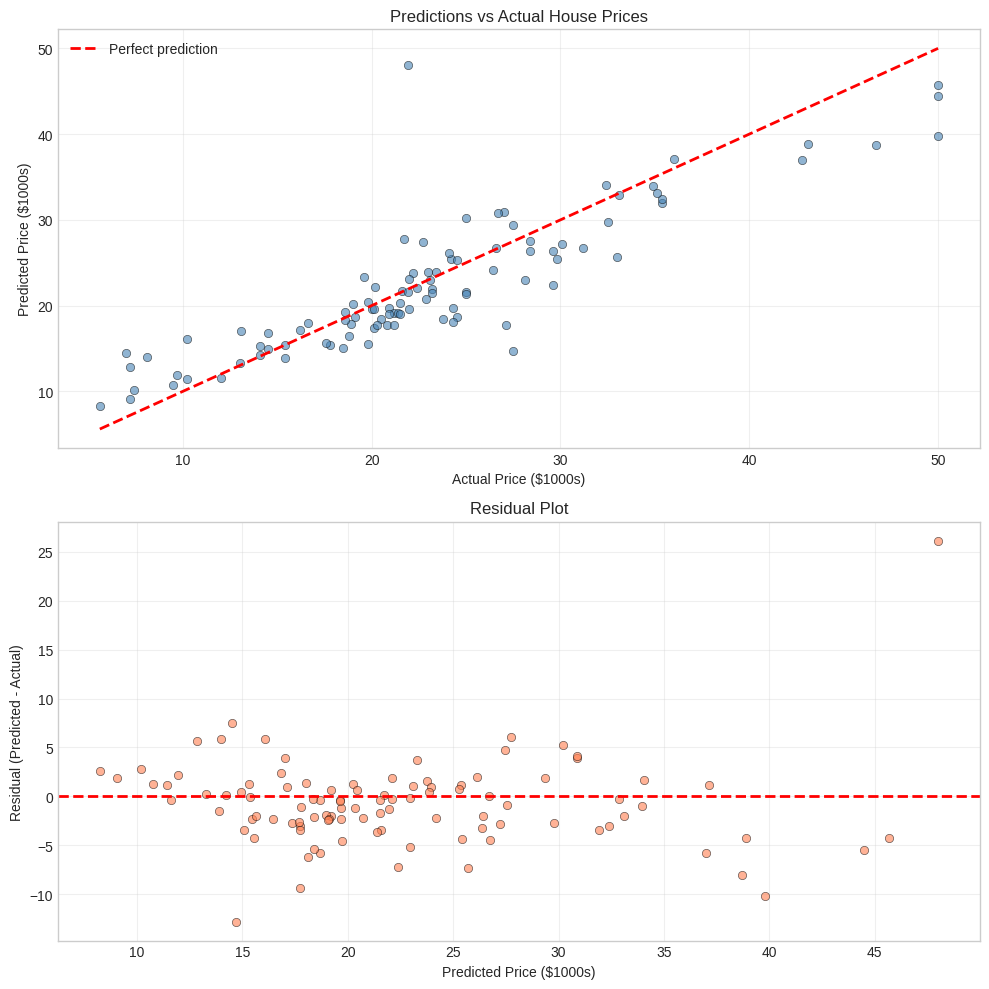

In [15]:
# Predictions vs Actual - Visualization
predictions = final_model.predict(test_data).flatten()

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Predictions vs Actual scatter plot
axes[0].scatter(test_targets, predictions, alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
max_val = max(test_targets.max(), predictions.max())
min_val = min(test_targets.min(), predictions.min())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Predictions vs Actual House Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residual plot
residuals = predictions - test_targets
axes[1].scatter(predictions, residuals, alpha=0.6, c='coral', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residual (Predicted - Actual)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()